# Pre Heating Analysis
Winter

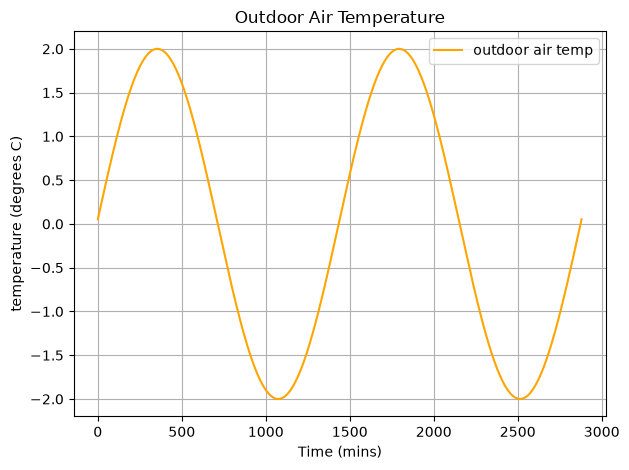

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import datetime

time_frame = 48 # [hours]
time_hours = np.linspace(0,time_frame,time_frame)
time_mins = np.linspace(0, time_frame * 60, time_frame * 60)

# Weather Curve
outdoor_air_temp = 2 * np.sin((np.pi/(12*60)) * time_mins + (np.pi/(2*60)))
upper_80_indoor_temp = (0.31*outdoor_air_temp) + 21.3
lower_80_indoor_temp = (0.31*outdoor_air_temp) + 14.3
indoor_air_temp = (upper_80_indoor_temp + lower_80_indoor_temp) / 2

# Price Curve
price = np.sin(time_mins)

# plot air temps
fig, ax = plt.subplots() 
ax.plot(time_mins, outdoor_air_temp, label='outdoor air temp', color='orange')
ax.set_xlabel('Time (mins)')
ax.set_ylabel('temperature (degrees C)')
ax.set_title('Outdoor Air Temperature')
ax.grid(True)

ax.legend()
plt.tight_layout()
plt.show()



## No Preheating
brainstorming: Preheating as an integer - when preheating = 0, no preheating, integer value = amount of time of preheating.

Body Specific Heat Capacity: 3500 
Average Body Mass: 62 
Average Body Temp Midpoint 36.2 
Sweat Limit: 36.5 

Energy Needed to Heat Person from midpoint to high range:
43400.0

 Watts of Heat that is needed to Pre-Heat the Human from neutral to the upper comfort limit:
[12.05555556  6.02777778  4.01851852  3.01388889  2.41111111  2.00925926]
The array index is the number of hours of preheating


C:\Users\khadi\AppData\Local\Temp\ipykernel_31568\1254292747.py:24: RuntimeWarning: divide by zero encountered in divide
  watts_of_preheating_needed = (energy_needed) / (time_mins * 60)


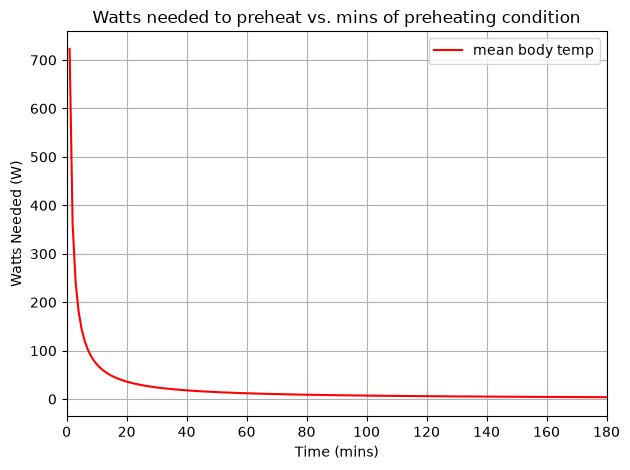

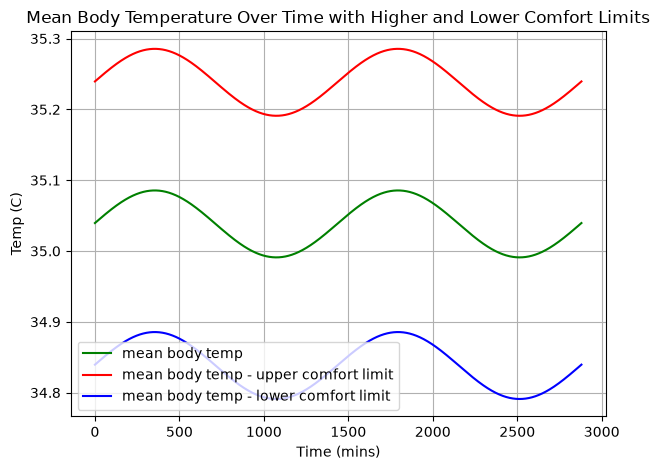

In [7]:
# Storage 

# Occupant Variables
met_rate = 65
work_rate = 0
body_cp = 3500
body_mass = 62
average_temp_midpoint = 36.2
surface_area_human = 1.8

mean_skin_temp = (0.3812 * (indoor_air_temp)) + 22.406 # get a more accurate model for skin temp
mean_core_temp = np.array([36.5] * len(time_mins))
mean_body_temp = ((0.2*mean_skin_temp) + (0.8*mean_core_temp))

thermal_flexibility_mean_body_temp = 0.2 # the human body can comfortably increase temperature by about 0.2 degrees before physiological temperature regulation kicks in.
energy_needed = body_cp * body_mass * thermal_flexibility_mean_body_temp
watts_per_hourly_range = np.empty(6)

for i in range(len(watts_per_hourly_range)) :
    watts_per_hourly_range[i] = energy_needed / ( (i+1) * 3600 )

print(f"Body Specific Heat Capacity: {body_cp} \nAverage Body Mass: {body_mass} \nAverage Body Temp Midpoint {average_temp_midpoint} \nSweat Limit: 36.5 \n\nEnergy Needed to Heat Person from midpoint to high range:\n{energy_needed}")
print(f"\n Watts of Heat that is needed to Pre-Heat the Human from neutral to the upper comfort limit:\n{watts_per_hourly_range}\nThe array index is the number of hours of preheating")
watts_of_preheating_needed = (energy_needed) / (time_mins * 60)
# plot change in watts needed to preheat over the preheating time period
fig, ax = plt.subplots()
ax.plot(time_mins, watts_of_preheating_needed, label='mean body temp', color='red')

ax.set_xlabel('Time (mins)')
ax.set_ylabel('Watts Needed (W)')
ax.set_title('Watts needed to preheat vs. mins of preheating condition')
ax.grid(True)

ax.legend()
plt.xlim(0,180)
plt.tight_layout()
plt.show()

# plot mean body temperature range
fig, ax = plt.subplots()
ax.plot(time_mins, mean_body_temp, label='mean body temp', color='green')
ax.plot(time_mins, mean_body_temp + 0.2, label='mean body temp - upper comfort limit', color='red')
ax.plot(time_mins, mean_body_temp - 0.2, label='mean body temp - lower comfort limit', color='blue')

ax.set_xlabel('Time (mins)')
ax.set_ylabel('Temp (C)')
ax.set_title('Mean Body Temperature Over Time with Higher and Lower Comfort Limits')
ax.grid(True)

ax.legend()
plt.tight_layout()
plt.show()

total heat loss from skin: [28.64095301 28.64905572 28.65715734 ... 28.62474492 28.63284936
 28.64095301]
total heat loss from respiration: [6.5 6.5 6.5 ... 6.5 6.5 6.5]
total heat transfer: [29.85904699 29.85094428 29.84284266 ... 29.87525508 29.86715064
 29.85904699]


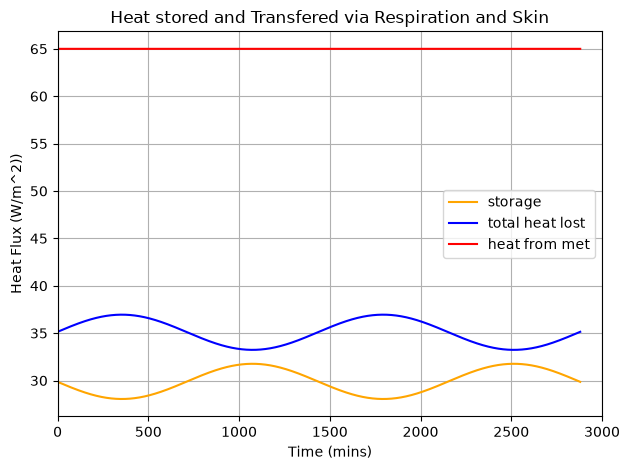

In [8]:
# Winter - No Pre-Heating Model

# Heat Balance Analysis

# HEAT LOSS VIA SKIN


# relevant temperatures in Kelvins
indoor_air_temp_k = indoor_air_temp + 273.15
mean_skin_temp_k = mean_skin_temp + 273.15
mean_body_temp_k = mean_body_temp + 273.15
mean_core_temp_k = mean_core_temp + 273.15
average_temp_midpoint_k = average_temp_midpoint + 273.15

# convective and radiative
i_clo = 0.61
r_clo = 0.155*i_clo
f_clo = 1.20 # trousers and long sleeved shirt [ASHRAE pg 9.8]
convective_heat_transfer_coefficient = 3.1
linear_radiative_heat_transfer_coefficient = 4.7
htc = convective_heat_transfer_coefficient+linear_radiative_heat_transfer_coefficient
r_c_ht = (mean_skin_temp - indoor_air_temp) / (r_clo + (1/(f_clo*htc)))

# evaporative
skin_wettedness = 0.06 # dry skin
p_sk = np.power(2.718,(77.3450+0.0057*(mean_skin_temp + 273.15)-7235/(mean_skin_temp+273.15)))/(np.power((mean_skin_temp+273.15),8.2))/1000
p_a = np.array([101.325] * len(time_mins)) # Convert p_a to a NumPy array
r_evap_clo = 0.020 # evaporative heat transfer resistance of clothing layer
evap_htc = 2.2 * htc # evaporative heat transfer coefficient [engineering data and measurements]
evap_ht = (skin_wettedness*(p_sk-p_a)) / (r_evap_clo + (1/(f_clo*evap_htc)))

# total heat loss from skin
q_sk = r_c_ht + evap_ht
q_sk = -q_sk

# HEAT LOSS VIA RESPIRATION
c_res = 0.0014 * met_rate * (34 - (indoor_air_temp+273.15))
e_res = 0.0173 * met_rate * (5.87 - p_a)
#e_res = np.array([15] * len(time_hours))
#print(f"c_res: {c_res}")
#print(f"e_res: {e_res}")
#q_res = c_res + e_res
q_res = np.array([met_rate * 0.1] * len(time_mins))

print(f"total heat loss from skin: {q_sk}\ntotal heat loss from respiration: {q_res}")
storage = met_rate - (q_sk + q_res)
#print(f"Storage:{storage}")

total_heat_transfer = met_rate - (q_sk + q_res)
print(f"total heat transfer: {total_heat_transfer}")

# graphing again!
fig, ax = plt.subplots() 
ax.plot(time_mins, storage, label='storage', color='orange')
ax.plot(time_mins, (q_sk+q_res), label='total heat lost', color='blue')
#ax.plot(time_hours, q_sk, label='heat loss from skin', color='blue')
#ax.plot(time_hours, q_res, label='heat loss from respiration', color='green')
ax.plot(time_mins, np.array([met_rate] * len(time_mins)), label='heat from met', color='red')

ax.set_xlabel('Time (mins)')
ax.set_ylabel('Heat Flux (W/m^2))')
ax.set_title('Heat stored and Transfered via Respiration and Skin')
ax.grid(True)

ax.legend()
plt.xlim(0,3000)
plt.tight_layout()
plt.show()


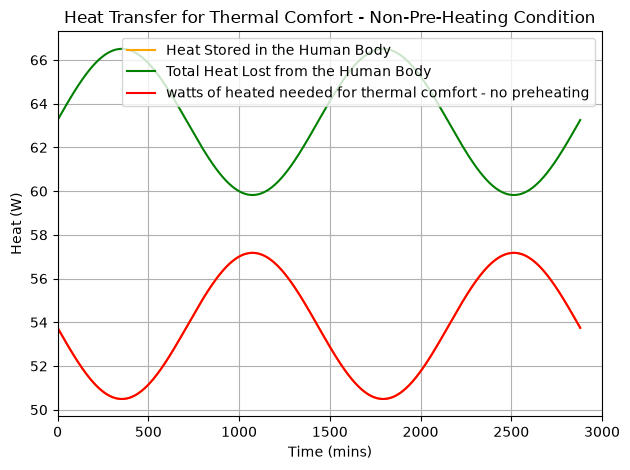

In [12]:
# No Pre-Heating Conclusions
# To achieve comfort with zero pre-heating, the human body should store a minimal amount of heat - as a result, the watts of heat that need to be inputted into the human body to 
# maintain comfort is equivalent to the storage.

watts_of_heat_needed_no_pre_heating = storage * surface_area_human

# Plot the No-Pre_Heating Condition
# Plot components - indoor air temp, heat loss, heat storage, watts inputted
fig, ax = plt.subplots() 
ax.plot(time_mins, storage * surface_area_human, label='Heat Stored in the Human Body', color='orange')
ax.plot(time_mins, (q_sk+q_res) * surface_area_human, label='Total Heat Lost from the Human Body', color='green')
ax.plot(time_mins, watts_of_heat_needed_no_pre_heating, label='watts of heated needed for thermal comfort - no preheating', color='red')


ax.set_xlabel('Time (mins)')
ax.set_ylabel('Heat (W)')
ax.set_title('Heat Transfer for Thermal Comfort - Non-Pre-Heating Condition')
ax.grid(True)

ax.legend()
plt.xlim(0,3000)
plt.tight_layout()
plt.show()


### Non Pre-Heating Condition Conclusions
The Human body is at optimal thermal comfort with thermal storage is closest to zero and is within +- 15 W [from comfortable heat analysis]
In the non-preheating condition, optimal thermal comfort is achieved by making the amount of heat provided to the human body equivalent to the watts of heat being stored by the human body. In this winter scenario,
the human body is storing large amounts of heat because the indoor temperture is lower. By providing an equivalent amount of heat, the human will stay at an optimal thermal comfort level.

## Pre-Heating Condition
Within the Pre=heating condition, we expand the range of thermal storage allowed - thermal storage within the human body is allowed to vary within a comfortable range defined by how much the mean body temperature can
comfortable change. According to the thermal storage analysis, if we have a flexibility range of about 0.2 C, then the human body can store an excess of about 43 kJ of heat. These 43kJ can  be distributed over a range of time depending on 1. how much time will be spent preheating and 2. how much time will be spent coasting.

In our analysis of the pre-heating condition, the amount of time necessary for coasting will be defined and the amount of time needed for pre-heating will be determined from there.